# EvoCA — test notebook

Tests the C core (ctypes), verifies exact GoL, and launches the SDL2 interactive display.

Run cells in order.  **Build first**, then proceed.

## 1  Build

In [1]:
import subprocess, sys, os
root = os.path.abspath('')
# macOS: gcc -dynamiclib; Linux: gcc -shared
import platform
flag = '-dynamiclib' if platform.system() == 'Darwin' else '-shared'
ext  = 'dylib'      if platform.system() == 'Darwin' else 'so'
cmd  = ['gcc', '-O2', '-Wall', '-fPIC', flag,
        '-o', f'C/libevoca.{ext}', 'C/evoca.c']
r = subprocess.run(cmd, cwd=root, capture_output=True, text=True)
print(r.stdout or '(no stdout)')
if r.returncode != 0:
    print('STDERR:', r.stderr, file=sys.stderr)
    raise RuntimeError('Build failed')
print('Build OK')

(no stdout)
Build OK


## 2  Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import time

from python.evoca_py import EvoCA, make_gol_lut, LUT_BYTES, lut_bit_index, unpack_lut
from python.display  import run as sdl_run
from python.controls import run_with_controls

/Users/n/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sdl2/dll.py:273: DLLWarning: OSError("dlopen(/usr/local/lib/libSDL2_ttf.dylib, 0x0006): tried: '/usr/local/lib/libSDL2_ttf.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/lib/libSDL2_ttf.dylib' (no such file), '/usr/local/lib/libSDL2_ttf.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/usr/local/lib/libSDL2_ttf-2.0.0.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/lib/libSDL2_ttf-2.0.0.dylib' (no such file), '/usr/local/lib/libSDL2_ttf-2.0.0.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64'))")
  warnings.warn(repr(exc), DLLWa

## 3  Interactive display — ipywidgets controls + SDL2 window

Controls appear in the cell output below; simulation renders in a separate SDL2 window.

- **Pause / Run** — toggle simulation
- **Step** — single step while paused
- **Quit** — close SDL2 window and return
- **Sliders** — adjust metaparams live; simulation auto-pauses during drag and resumes after
- **Color** dropdown — switch between state / env-food / priv-food views
- SDL2 keyboard: `SPACE` pause · `C` colour · `S` step · `Q`/`Esc` quit

In [3]:
gol_lut = make_gol_lut()

In [ ]:
N = 512
rng2 = np.random.default_rng(0)

params = {'N':N,
          'food_inc':0.12,
          'm_scale':0.2,
          'mu_lut':0.001,
          'tax':0.1,
          'restricted_mu':True}
sim = EvoCA()
sim.init(**params)
#sim.set_lut_all(gol_lut)
sim.set_lut_random(n_init=1)
sim.set_egenome_all(0b000011)
sim.set_v(rng2.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.1)
sim.set_F_all(0.5)

#run_with_controls(sim,paused=True)
#run_with_control(sim, paused=True, probes={'activity':True,'env_food': True, 'priv_food': True})
run_with_controls(sim, probes={'lut_complexity': True, 'activity': True},diag=True)
# Cell returns immediately.  Use widgets or Q/Esc in the SDL2 window to stop.

In [ ]:
N = 512
rng2 = np.random.default_rng(0)

params = {'N':N,
          'food_inc':0.12,
          'm_scale':0.2,
          'mu_lut':0.001,
          'tax':0.1,
          'n_ent':2,
          'restricted_mu':True}
sim = EvoCA()
sim.init(**params)
#sim.set_lut_all(gol_lut)
sim.set_lut_random(n_init=1)
sim.set_egenome_all(0b000011)
sim.set_v(rng2.integers(0, 2, (N, N), dtype=np.uint8))
sim.set_f_all(0.1)
sim.set_F_all(0.5)

#run_with_controls(sim,paused=True)
#run_with_control(sim, paused=True, probes={'activity':True,'env_food': True, 'priv_food': True})
#run_with_controls(sim, probes={'lut_complexity': True, 'activity': True},diag=True)
run_with_controls(sim, probes={
      'activity': True,
      'entropy': True,        # cyan line chart, auto-scaled Y axis
      'pat_activity': True,   # scrolling strip chart of pattern diversity
  })


# Cell returns immediately.  Use widgets or Q/Esc in the SDL2 window to stop.

In [9]:
h = sim.get_repro_age_hist()

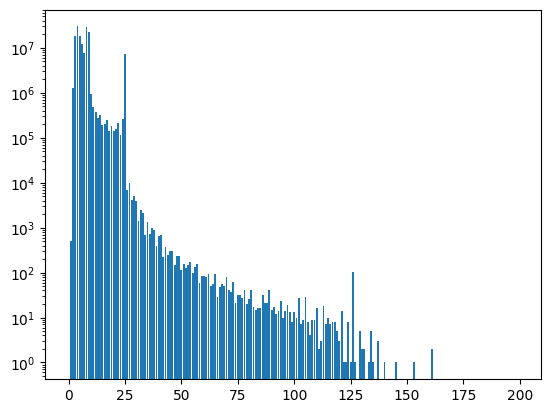

In [15]:
nn=200
plt.bar(range(nn),h[:nn]);
ax=plt.gca()
ax.set_yscale('log')

In [12]:
h[:60]

array([       0,        0,        0,        0,        0,        0,
              0,        0,        0,        0,        0,        0,
              0,        6,       56,      437,     3308,    21682,
         116215,   507114,  1724743,  4623166, 10280849, 25243811,
        6114602,  2359513,   806212,   223672,    57124,    12897,
           3141,      726,      293,       76,       64,        9,
             19,        7,       17,        3,        8,        0,
              3,       47,     4730,    65690,   149594,    30104,
              1,        0,        1,        0,        1,        0,
              0,        0,        1,        0,        0,        0],
      dtype=uint32)

In [32]:
foo=sim_sdl.get_lut(1)
len(foo)

32

In [33]:
foo

array([  0, 128,  15,   0, 248,   0,   4,  15,   4, 248,  64,  64,   1,
         1,  32,   8, 149, 255,   1, 232,  31, 144, 255,  65,  68,  31,
         2, 128,   4,   2,  12,   0], dtype=uint8)

In [22]:
food = sim_sdl.get_F()
len(food)

512

In [18]:
len(food)

0

In [13]:
import seaborn as sns

<Axes: ylabel='Density'>

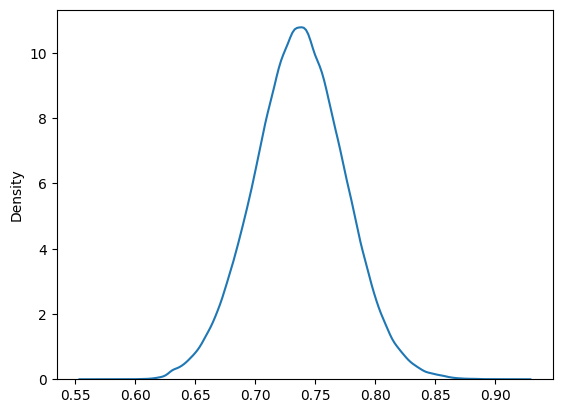

In [23]:
sns.kdeplot(data=food.flatten())

## 7  GoL-only SDL2 display  (food/repro disabled)

Use this to observe pure GoL dynamics with mutation=0.

In [ ]:
N = 512
rng3 = np.random.default_rng(7)

sim_gol = EvoCA()
sim_gol.init(N, food_inc=0.0, m_scale=0.0)
sim_gol.set_lut_all(gol_lut)
sim_gol.set_egenome_all(0)
sim_gol.set_v(rng3.integers(0, 2, (N, N), dtype=np.uint8))
sim_gol.set_f_all(0.0); sim_gol.set_F_all(0.0)

sdl_run(sim_gol)   # blocks until window closed
sim_gol.free()